### **P P2. Clasificación**
---

La infertilidad es un problema común que afecta a 1 de cada 6 parejas (Brugo-Olmedo et al., 2003). De acuerdo con este mismo artículo, las causas del incremento en infertilidad son difíciles de estables, pero principalmente se pueden deber a 4 factores:
- Postergación del momento en el que se decide tener hijos
- Alteraciones en la calidad del semen debido a distintos hábitos nocivos
- Cambios en conducta sexual
- Cambios socioculturales, como la eliminación de tabúes


En este proyecto se busca hacer un análisis del segundo factor mencionado.
Para esto, se usará la base de datos obtenida de [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/244/fertility). Estos datos fueron obtenidos de 100 voluntarios sanos estudiantes de la Universidad de Alicante de edades de entre 18 y 36 años. Se les pidió una muestra de semen posterior a 3 a 6 días de abstinencia, para después analizar la muestra de acuerdo a la guía de la Organización Mundial de la Salud. Se puede ver más información con respecto a las muestras en la subsección *"2.1 Study population"* del artículo *[Predicting seminal quality with artificial intelligence methods](https://doi.org/10.1016/j.eswa.2012.05.028)*. Aquellos que ya sabían que padecían alguna alteración reproductiva no fueron incluidos en el estudio.


A estas mismas personas se les pidió responder un cuestionario con respecto a sus hábitos, estilo de vida y estatus de salud. Los datos proporcionados por la este estudio ya están normalizados y no existen valores faltantes (de acuerdo con la información en el sitio). Estos datos fueron publicados en el 2013.


A continuación se hablará brevemente sobre las variables. Fueron previamente normalizadas por las personas que crearon la base de datos. Para más información se puede visitar el artículo anteriormente mencionado, en la sección *"2.2 Variables of the questionnaire"*. Esta base de datos sólo cuenta con pocas variables, a diferencia del estudio original.  


| Descripción variable | Valores (min. y max.) | Normalizada |
|-----------|-----------|-----------|
| Estación en la que el análisis fue realizado    | (1) invierno, (2) primavera, (3) verano, (4) otoño    | (-1, -0.33, 0.33, 1)    |
| Edad  | 18-36    | Valores entre 0 y 1    |
| Enfermedades en la infancia (i. e. sarampión, paperas, varicela, polio) | (1) Sí, (2) No | (0, 1) |
| Accidentes o traumas serios | (1) Sí, (2) No | (0, 1) |
| Intervenciones quirurgicas | (1) Sí, (2) No | (0, 1) |
| Fiebres altas en los últimos años | (1) hace menos de 3 meses, (2) hace más de 3 meses, (3) no | (-1, 0, 1)|
| Frecuencia de consumo de alcohol | (1) varias veces al día, (2) todos los días, (3) varias veces a la semana, (4) una vez a la semana, (5) casi nunca o nunca | Valores entre 0 y 1|
| Hábito de fumar | (1) nunca, (2) ocasionalmente, (3) diario | (-1, 0, 1)|
| Número de horas que pasan sentados por día | 1-16 | Valores entre 0 y 1|
| Diagnóstico | (1) Normal, (2) Alterado | (N, O) |




(Fertility - UCI Machine Learning Repository, 2013)


La variable de salida es en este reporte será si la muestra muestra alteraciones y está normal. Con esto, se busca tener un mejor entendimiento de qué factores pudieran estar afectando la fertilidad de un hombre y poder hacer algo al respecto, en especial aquellos que están interesados en tener hijos, o simplemente como referencia para los centros de donación.


---


Ahora, se comenzará cargando la base de datos a la zona de trabajo importando la librería `pandas`. Debido a que la base de datos está en UC Irvine Machine Learning Repository, se guarda el url del archivo en una variable, para después leer esta información usando `read_csv`, dándole como parámetros el url de los datos, separándolos con comas y no agregándole `header`. Posteriormente, se imprimen las primeras 10 filas de la base de datos con `head(10)`.  





In [ ]:
import pandas as pd

# URL to the dataset file
data_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00244/fertility_Diagnosis.txt'

# Load the dataset. Assuming it's tab-separated based on .txt extension in UCI datasets.
# Also, UCI datasets often don't have headers, so we set header=None.
df = pd.read_csv(data_url, sep=',', header=None)

# Display the first 10 rows of the DataFrame
display(df.head(10))

,0,1,2,3,4,5,6,7,8,9
0,-0.33,0.69,0,1,1,0,0.8,0,0.88,N
1,-0.33,0.94,1,0,1,0,0.8,1,0.31,O
2,-0.33,0.50,1,0,0,0,1.0,-1,0.50,N
3,-0.33,0.75,0,1,1,0,1.0,-1,0.38,N
4,-0.33,0.67,1,1,0,0,0.8,-1,0.50,O
5,-0.33,0.67,1,0,1,0,0.8,0,0.50,N
6,-0.33,0.67,0,0,0,-1,0.8,-1,0.44,N
7,-0.33,1.00,1,1,1,0,0.6,-1,0.38,N
8,1.00,0.64,0,0,1,0,0.8,-1,0.25,N
9,1.00,0.61,1,0,0,0,1.0,-1,0.25,N


Como se puede observar, los datos no cuentan con títulos de las variables, por lo que se agregarán los nombres de estas variables a una variable llamada `column_names` para después agregarlas como columnas usando la función `df.columns`.  


Además, se ajustará la variable `Diagnosis` a 0 y 1 para que pueda funcionar con los modelos. Para esto se usa la función `map` para la columna `Diagnosis` y se le pide que las letras `N` (Normal) sean convertidos a 0 y que las letras `O` (Alterada) sean convertidas a 1. Para comprobar que se haya ejecutado correctamente, se imprimen las primeras 10 filas, usando la misma función que en el paso pasado.







In [ ]:
column_names = [
    'Season',
    'Age',
    'Childish diseases',
    'Accident or serious trauma',
    'Surgical intervention',
    'High fevers in the last year',
    'Frequency of alcohol consumption',
    'Smoking habit',
    'Number of hours spent sitting per day',
    'Diagnosis'
]
df.columns = column_names

df['Diagnosis'] = df['Diagnosis'].map({'N': 0, 'O': 1})

# Display the first 10 rows with the new column names and change in variable "Diagnosis"
display(df.head(10))

,Season,Age,Childish diseases,Accident or serious trauma,Surgical intervention,High fevers in the last year,Frequency of alcohol consumption,Smoking habit,Number of hours spent sitting per day,Diagnosis
0,-0.33,0.69,0,1,1,0,0.8,0,0.88,0
1,-0.33,0.94,1,0,1,0,0.8,1,0.31,1
2,-0.33,0.50,1,0,0,0,1.0,-1,0.50,0
3,-0.33,0.75,0,1,1,0,1.0,-1,0.38,0
4,-0.33,0.67,1,1,0,0,0.8,-1,0.50,1
5,-0.33,0.67,1,0,1,0,0.8,0,0.50,0
6,-0.33,0.67,0,0,0,-1,0.8,-1,0.44,0
7,-0.33,1.00,1,1,1,0,0.6,-1,0.38,0
8,1.00,0.64,0,0,1,0,0.8,-1,0.25,0
9,1.00,0.61,1,0,0,0,1.0,-1,0.25,0


Ahora, se separarán los datos que se usarán para calcular la variable de salida y la variable de salida en `X` y `y`, respectivamente. Se "deja" la columna `Diagnosis` (para no incluirla en las variables de entrada) usando la función `drop` y agregando el nombre de la columna que no se va a agregar. Después, se guarda la columna `Diagnosis` en `y`.

Para que la evaluación y comparación de los modelos sea equitativa, se hará la división de `train` y `test` desde el inicio y estos sets se usarán para entrenar y probar todos los modelos. Además, es importante hacer esta separación para que no haya fuga de datos. Se hará una separación `train` 70% y `test` 30%, debido a que es una base de datos pequeña. Esto se logra importando la librería `train_test_split` (que permite hacer esta separación) y usando la función con el mismo nombre. Se le da de parámetros las variables a partir (en este caso `X` y `y`), además del tamaño de la prueba, una semilla de de aleatoriedad para que el resultado pueda ser replicable y agregando `stratify=y` para que haya proporción de cada clase en ambas particiones y así el modelo no se exponga a overfitting o sólo aprenda con una clase.

A su vez, se buscarán posibles outliers, usando el método de rango intercuartil, para todos los valores de `X_train`.  




In [ ]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = df.drop('Diagnosis', axis=1) # All columns except 'Diagnosis'
y = df['Diagnosis']             # Only the 'Diagnosis' column

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

print("\nValue counts for y_train (stratified):")
print(y_train.value_counts(normalize=True))

print("\nValue counts for y_test (stratified):")
print(y_test.value_counts(normalize=True))

Shape of X_train: (70, 9)
Shape of X_test: (30, 9)
Shape of y_train: (70,)
Shape of y_test: (30,)

Value counts for y_train (stratified):
Diagnosis
0    0.885714
1    0.114286
Name: proportion, dtype: float64

Value counts for y_test (stratified):
Diagnosis
0    0.866667
1    0.133333
Name: proportion, dtype: float64


### **Identificación de Outliers**

Antes de aplicar SMOTE, es importante identificar y entender la presencia de outliers en los datos de entrenamiento, ya que estos pueden afectar el rendimiento del modelo y la generación de muestras sintéticas. Se utilizarán métodos estadísticos y visualizaciones para detectarlos.

Primero, se mostrarán estadísticas descriptivas de `X_train` para obtener una visión general de la distribución de las variables. Este método cualquier valor que cae por debajo de $Q_1 - 1.5 \times IQR$ o por encima de $Q_3 + 1.5 \times IQR$, donde $Q_1$ es el primer cuartil, $Q_3$ es el tercer cuartil, e $IQR = Q_3 - Q_1$.

Para lograr esto, se crea un `for` loop, para recorrer cada columna en búsqueda de posibles outliers. Después se encuentra el `Q1` y `Q3` de cada columna, usando la función `quantile()` y agregando como parámetro el cuartil que se busca. Esto se hace para los valores de `X_train`. Posteriormente se calcula el Rango Intercuartil (`IQR`) restando `Q3` y `Q1`. Se establecen los límites, menor y mayor, para poder detectar los valores atípicos, restándole 1.5*IQR a Q1, y sumándoles esta misma cantidad a Q3.

Luego se imprimen los posibles outliers detectados para cada variables, para poder analizarlos más a detalle y determinar qué se debe hacer con ellos.

In [ ]:
for column in X_train.columns:
    Q1 = X_train[column].quantile(0.25)
    Q3 = X_train[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = X_train[(X_train[column] < lower_bound) | (X_train[column] > upper_bound)]
    print(f"Number of outliers in {column}: {len(outliers)}")
    if len(outliers) > 0:
        print(f"Outlier values in {column}:\n{outliers[column]}\n")

Number of outliers in Season: 0
Number of outliers in Age: 0
Number of outliers in Childish diseases: 9
Outlier values in Childish diseases:
65    0
99    0
0     0
8     0
59    0
32    0
29    0
6     0
20    0
Name: Childish diseases, dtype: int64

Number of outliers in Accident or serious trauma: 0
Number of outliers in Surgical intervention: 0
Number of outliers in High fevers in the last year: 0
Number of outliers in Frequency of alcohol consumption: 2
Outlier values in Frequency of alcohol consumption:
58    0.4
14    0.2
Name: Frequency of alcohol consumption, dtype: float64

Number of outliers in Smoking habit: 0
Number of outliers in Number of hours spent sitting per day: 2
Outlier values in Number of hours spent sitting per day:
0     0.88
70    0.88
Name: Number of hours spent sitting per day, dtype: float64



Con respecto a los posibles outliers, teniendo en cuenta los rangos en los que están las variables, ninguno es realmente un outlier, sólamente hay muy pocas muestras con esos mismo variables y es por eso que quedan fuera de los valores límite.


con respecto a la proporción entre clases, se puede observar, hay un gran desbalance entre clases. Esto podría causar que el modelo tenga un sesgo hacia la clase con mayor cantidad de registros (clase 'Normal') lo que puede llevar a un mal desempeño del modelo a la hora de predecir las muestras con alguna alteración. Es por eso que, de acuerdo con GeeksforGeeks (2026) se puede usar SMOTE (Synthetic Minority Over-sampling Technique) que ayuda a lidiar con este problema al crear muestras sintéticas para la clase minoritaria. Así, se puede crear una base de datos más balanceada y ayuda a los modelos a poder aprender con condiciones equitativas para ambas clases.


Este método funciona de la siguiente manera:
- Se identifica la clase con menor cantidad de muestra
- Se encuentran los vecinos más cercanos. Para cada muestra, SMOTE localiza el k vecino más cercano (este valor de k se establece por el usuario)
- Se generan las muestras sintéticas. A partir de los puntos generados, se genera un nuevo dato con valores intermedios, para no crear ejemplos iguales sino diferentes y realistas.
- Se tiene un control de la cantidad de muestras sintéticas creadas, creando muestras hasta que ambas clases tengan una cantidad similar de muestras o al balance que se quiera obtener. (GeeksforGeeks, 2026)




Estos pasos se pueden repetir para todas las clases desbalanceadas. En este caso, sólo se hará para una clase ('Alterado').


Para hacer esto con la base de datos que se tiene se debe importar la librería `SMOTE`. Se establece un valor de aleatoriedad para este método para que pueda ser replicable. Posteriormente se crean valores sintéticos para `X` y `y` usando la función `smote.fit_resample` y se guardan en las variables `X_train_resampled` y `y_train resampled`. Por último, se imprime el tamaño nuevo del conjunto de datos de entrenamiento, además de la proporción de datos por cada clase para confirmar que ahora sí estén equilibradas las clases.


Este proceso sólo se hace con el conjunto de datos de `train` para que no haya fuga de datos, debido a que hace estas muestras sintéticas basándose en información real.





In [ ]:
pip install imblearn

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Shape of X_train after SMOTE:", X_train_resampled.shape)
print("Shape of y_train after SMOTE:", y_train_resampled.shape)

print("\nValue counts for y_train after SMOTE (resampled):")
print(y_train_resampled.value_counts(normalize=True))

Shape of X_train after SMOTE: (124, 9)
Shape of y_train after SMOTE: (124,)

Value counts for y_train after SMOTE (resampled):
Diagnosis
1    0.5
0    0.5
Name: proportion, dtype: float64


Se puede observar que ahora se tienen 124 filas para este conjunto de datos, a diferencia de los 80 con los que se inició. Como se puede ver, ahora los datos tienen una proporción 50-50, por lo que una clase no predominará cuando se esté entrenando al modelo.



Ahora que ya se importaron los datos y se trabajaron previamente, se comenzará a trabajar en la construcción de los modelos. En este reporte se construirán los siguientes:
- Regresión Logística
- Linear Discriminant Analysis (LDA)
- Random Forest
- Support Vector Machines
- Redes neuronales


Para la creación de todos los modelos se utilizará una semilla de aleatoriedad para que esto sea reproducible.
---
#### **1. Regresión Logística**


Para comenzar, se importan las librerías `LogosticRegression` (para crear el modelo) y `accuracy_score`y  `classification_report`, para poder calcular las métricas necesarias para evaluar el desempeño del modelo. Además, se cargan las librerías `confussion_matrix`, `matplotlib.pyplot` y `ConfusionMatrixDisplay` para poder calcular la matriz de confusión y posteriormente graficarla con un "heatmap", para mayor comprensión visual.




Después se crea un modelo de regresión logística, optimizando la regresión logística con `solver='liblinear'` para una base de datos pequeña, usando una semilla de aleatoriedad para siempre obtener la misma división y mismos resultados.


Con `log_reg.fit()` se entrena el modelo; aprende los coeficientes y ajusta la regresión logística, usando como entrada los datos de `X` de entrenamiento y los datos de `y`. Luego se hacen las predicciones, usando la función `log_reg.predict()`, donde arrojará valores para `y` basándose en los valores existentes de `X` del conjunto de entrenamiento. Por último se calculan las métricas (`accuracy_socre`, `clasificaction_report` y `confusion_matrix`) y se imprimen con la función `print`.









In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Initialize the Logistic Regression model
log_reg = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' is good for small datasets and handles L1/L2 regularization

# Train the model using the resampled training data
log_reg.fit(X_train_resampled, y_train_resampled)

# Make predictions on the resampled training set (for evaluation on training data)
y_pred_log_reg_train = log_reg.predict(X_train_resampled)

# Evaluate the model on the resampled training data
print("Logistic Regression Model Evaluation on Resampled Training Data:")
print("Accuracy:", accuracy_score(y_train_resampled, y_pred_log_reg_train))
print("\nClassification Report:\n", classification_report(y_train_resampled, y_pred_log_reg_train))
print("\nConfusion Matrix:\n", confusion_matrix(y_train_resampled, y_pred_log_reg_train))

Logistic Regression Model Evaluation on Resampled Training Data:
Accuracy: 0.8467741935483871

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.79      0.84        62
           1       0.81      0.90      0.85        62

    accuracy                           0.85       124
   macro avg       0.85      0.85      0.85       124
weighted avg       0.85      0.85      0.85       124


Confusion Matrix:
 [[49 13]
 [ 6 56]]


#### **Métricas del modelo en entrenamiento**
* **Acuracy**: 85% de las predicciones totales fueron correctas.
* **Precision** (clase 0 "Normal"): 89% de las veces que el modelo predijo que la muestra estaba normal en realidad sí estaba normal.
* **Recall** (clase 0 "Normal"): 79%, el modelo logró captar este porcentaje del 100% de las muestras del conjunto que sí estaban normales.
* **F1-score** (clase 0 "Normal"): 84%, promedio armónico entre **precision** y **accuracy** de esta clase.
* **Precision** (clase 1 "Alterada"): 81% de las veces que el modelo predijo que la muestra estaba alterada en realidad sí estaba alterada.
* **Recall** (clase 1 "Alterada"): 90%, el modelo logró captar este porcentaje del 100% de las muestras del conjunto que sí estaban alteradas.
* **F1-score** (clase 1 "Alterada"): 85%, promedio armónico entre **precision** y **accuracy** de esta clase.


El modelo parece mostrar buena capacidad predictiva, con sólo 11 muestras marcadas como "Normal" que realmente eran "Alterada", dato obtenido de la matriz de confusión. Para ambas clases, tienen altos niveles de precisión y sensibilidad, al igual que f1-score; todos rondando en los 80%.


Ahora, para ver cómo se comporta el modelo en los datos no vistos por el modelo, se usarán los datos de `X_test` para crear predicciones de `y`. Posteriormente se calculan e imprimen las mismas métricas anteriormente mencionadas. Además, se agrega un heatmap de la matriz de confusión para una mejor visualización y entendimiento de los números obtenidos, usando la función `ConfusionMatrixDisplay`.





In [ ]:
# Make predictions on the test set
y_pred_log_reg_test = log_reg.predict(X_test)

# Evaluate the model on the test data
print("Logistic Regression Model Evaluation on Test Data:")
print("Accuracy:", accuracy_score(y_test, y_pred_log_reg_test))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log_reg_test))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_log_reg_test))

Logistic Regression Model Evaluation on Test Data:
Accuracy: 0.6333333333333333

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.69      0.77        26
           1       0.11      0.25      0.15         4

    accuracy                           0.63        30
   macro avg       0.48      0.47      0.46        30
weighted avg       0.76      0.63      0.68        30


Confusion Matrix:
 [[18  8]
 [ 3  1]]


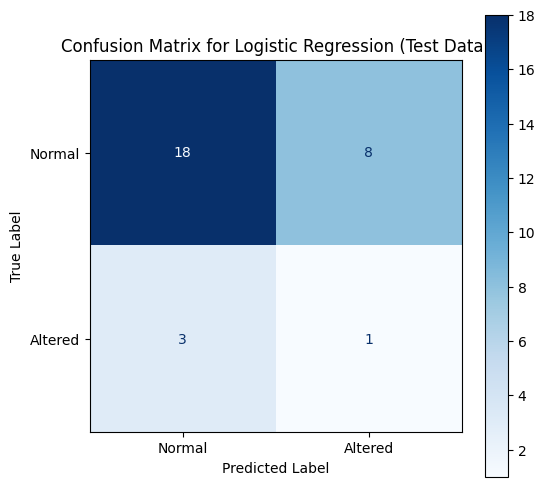

In [ ]:
# Define the labels for the classes
class_labels = ['Normal', 'Altered']

# Create the confusion matrix display with values inside the cells for the test set
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_log_reg_test, display_labels=class_labels, cmap=plt.cm.Blues, ax=ax, values_format='d')

# Add titles and labels for clarity
ax.set_title('Confusion Matrix for Logistic Regression (Test Data)')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')

plt.grid(False) # Turn off grid for confusion matrix
plt.show()

#### **Métricas del modelo en prueba**
* **Acuracy**: 63% de las predicciones totales fueron correctas
* **Precision** (clase 0 "Normal"): 86% de las veces que el modelo predijo que la muestra estaba normal en realidad sí estaba normal
* **Recall** (clase 0 "Normal"): 69%, el modelo logró captar este porcentaje del 100% de las muestras del conjunto que sí estaban normales.
* **F1-score** (clase 0 "Normal"): 77%, promedio armónico entre **precision** y **accuracy** de esta clase.
* **Precision** (clase 1 "Alterada"): 11% de las veces que el modelo predijo que la muestra estaba alterada en realidad sí estaba alterada
* **Recall** (clase 1 "Alterada"): 25%, el modelo logró captar este porcentaje del 100% de las muestras del conjunto que sí estaban alteradas.
* **F1-score** (clase 1 "Alterada"): 15%, promedio armónico entre **precision** y **accuracy** de esta clase.


De las 4 muestras alteradas que había en este conjunto de datos, sólo logró identificar 1. Aunque, sí logró identificar 69% de las muestras que realmente estaban normales y de las veces que predijo que una muestra estaba "Normal" estaba en lo correcto 86% de las veces. Esto indica que el modelo es moderadamente bueno en identificar las muestras normales, pero se le dificulta identificar las muestras alteradas. Sin embargo, se debe considerar que la base de datos está altamente desbalanceada, con sólo 4 valores marcados como "Alterado".


Para continuar, se hará la curva ROC para visualizar el desempeño del modelo en diferentes umbrales. La curva grafica la tasa de Verdaderos positivos (Sensibilidad) contra la tasa de Falsos Positivos (1 - especificidad). También se calculará el área bajo la curva (AUC) con la intención de ver el desempeño del modelo.




Para hacer esto, se importa la librería `roc_curve` y `roc_auc_score`, para poder usar sus funciones que permitan estos cálculos. Después se calculan la tasa de Falsos Positivos (`fpr`), la tasa de Verdaderos Positivos (`tpr`) y todos los posibles umbrales (`threshold`). Posteriormente se pasa a graficar la curva con `plt.figure`, agregando límites de 0 a 1 para ambos ejes, añadiendo nombres a los ejes; `False Positive Rate` para el eje `x` y `True PositiveRate` para el eje `y`. Se muestra la gráfica con `plt.show()`. Además, para mejor visualización, se le agrega una cuadrícula con `plt.grid(True)`.







In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

# Get probabilities for the positive class (1)
y_pred_proba_log_reg_test = log_reg.predict_proba(X_test)[:, 1]

# Calculate AUC score
auc_log_reg_test = roc_auc_score(y_test, y_pred_proba_log_reg_test)
print(f"AUC Score for Logistic Regression (Test Data): {auc_log_reg_test:.4f}")

AUC Score for Logistic Regression (Test Data): 0.4135


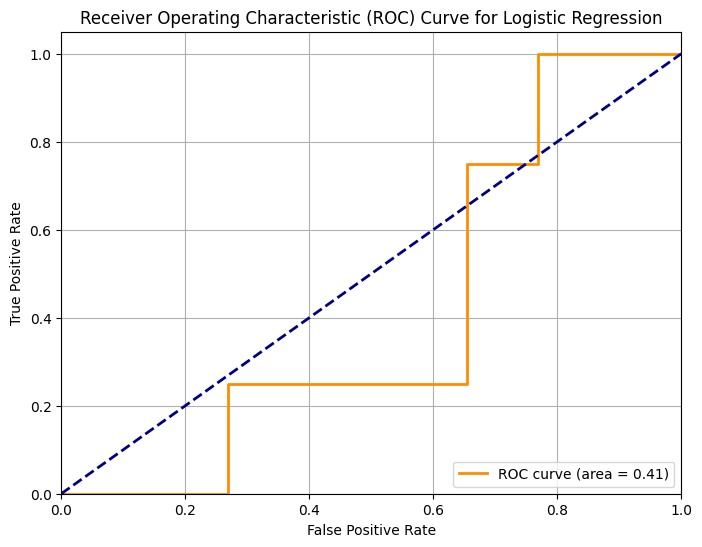

In [ ]:
import matplotlib.pyplot as plt

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_log_reg_test)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {auc_log_reg_test:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Logistic Regression')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

La curva ROC muestra un área bajo la curva (AUC) de 0.41, lo que indica un desempeño inferior al azar. Este resultado puede decir que el modelo no logra discriminar bien entre ambas clases, posiblemente debido al desbalance de los datos, la limitada capacidad explicativa de las variables utilizadas o posibles problemas en la especificación del modelo.

Debido a eso, se puede decir que el modelo en su estado actual no es adecuado para la tarea de clasificación de las muestras seminales.

#### **2. Linear Discriminant Analysis (LDA)**

Ahora, se trabajará con un modelo LDA.
Este modelo asume normalidad en las variables independientes. Las variables binarias no siguen este tipo de distribución. En esta base de datos se cuentan con 3 variables de este tipo, pero se mantendrán debido a que aportan información importante sobre el estilo de vida de la persona.


Ahora, se hará la creación y entrenamiento del modelo LDA. Para comenzar, se importa la librería `LinearDiscriminantAnalysis` que permitirá utilizar las funciones que crearán y entrenarán a este tipo de modelo. Se inicializa el modelo LDA usando la función `LinearDiscriminantAnalysis()`. Estableciendo esto, se asume que los datos tienen una distribución normal y que las clases comparten la misma matriz de covarianza. Con este método se genera una frontera de decisión lineal.
Luego, se usa la función `fit()` que se encarga de ajustar un modelo a los valores de `X_train_resampled`, considerando `y_train_resampled`.


Se imprimen las mismas métricas que para el modelo anterior, usando las mismas funciones e imrpimiéndolas.


**Para la matriz de confusión, el eje `x` indica "Predicted Class", mientras que el eje `y` indica "True Lable". La primera fila corresponde a la clase "Normal", al igual que la primera columna pertenece a esta clase. Este acomodo aplica para todas las matrices de confusión de este reporte.*

























In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Initialize the LDA model
lda = LinearDiscriminantAnalysis()

# Train the model using the resampled training data
lda.fit(X_train_resampled, y_train_resampled)

# Make predictions on the resampled training set
y_pred_lda_train = lda.predict(X_train_resampled)

# Evaluate the model on the resampled training data
print("Linear Discriminant Analysis Model Evaluation on Resampled Training Data:")
print("Accuracy:", accuracy_score(y_train_resampled, y_pred_lda_train))
print("\nClassification Report:\n", classification_report(y_train_resampled, y_pred_lda_train))
print("\nConfusion Matrix:\n", confusion_matrix(y_train_resampled, y_pred_lda_train))

Linear Discriminant Analysis Model Evaluation on Resampled Training Data:
Accuracy: 0.8709677419354839

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.79      0.86        62
           1       0.82      0.95      0.88        62

    accuracy                           0.87       124
   macro avg       0.88      0.87      0.87       124
weighted avg       0.88      0.87      0.87       124


Confusion Matrix:
 [[49 13]
 [ 3 59]]


#### **Métricas del modelo en entrenamiento**
* **Acuracy**: 87% de las predicciones totales fueron correctas.
* **Precision** (clase 0 "Normal"): 94% de las veces que el modelo predijo que la muestra estaba normal en realidad sí estaba normal
* **Recall** (clase 0 "Normal"): 79%, el modelo logró captar este porcentaje del 100% de las muestras del conjunto que sí estaban normal.
* **F1-score** (clase 0 "Normal"): 86%, promedio armónico entre **precision** y **accuracy** de esta clase.
* **Precision** (clase 1 "Alterada"): 82% de las veces que el modelo predijo que la muestra estaba alterada en realidad sí estaba alterada
* **Recall** (clase 1 "Alterada"): 95%, el modelo logró captar este porcentaje del 100% de las muestras del conjunto que sí estaban alteradas.
* **F1-score** (clase 1 "Alterada"): 88%, promedio armónico entre **precision** y **accuracy** de esta clase.


Este modelo, con datos de entrenamiento, tiene un desempeño muy similar al modelo de Regresión Logística. Parecería poder ser capaz de diferenciar entre ambas clases, con f1-scores mayores a 80%.


Para tener un mejor entendimiento de cómo está funcionando el modelo y qué está tomando a consideración, se imprimirán los coeficientes de cada variable, al igual que la función discriminante.


El límite de decisión es calculado con la siguiente fórmula:
$$
x^* = \frac{\hat{\mu}_1^2 - \hat{\mu}_2^2 + 2\hat{\sigma}^2 \left( \ln(\hat{\pi}_2) - \ln(\hat{\pi}_1) \right)}{2(\hat{\mu}_1 - \hat{\mu}_2)}
$$


Debido a que se tienen clases balanceadas (0.5 y 0.5),
$$
\hat{\pi}_1 = \hat{\pi}_2
$$
Entonces, $$ ln(\hat{\pi}_2) - \hat{\pi}_1 = 0
$$
Por lo que la fórmula se simplifica a
$$
x^* = \frac{\hat{\mu}_1^2 - \hat{\mu}_2^2}{2(\hat{\mu}_1 - \hat{\mu}_2)}
$$


Y simplificando aún más, se obtiene
$$
x^* = \frac{\hat{\mu}_1 + \hat{\mu}_2}{2}
$$


Siendo $\hat{\mu}_i$ la media de la clase correspondiente, se obtiene la media por cada clase con la función `mean`. Posteriormente se calcula el límite de decisión sumando las medias y dividiéndolas entre 2 y se muestra.




Después, se imprimen los coeficientes usando un `for` loop y usando la función `lda.coef` para cada variable. Después se imprime el intercepto de esta función con `lda.intercept`. Luego, para imprimir la función, se comienza por imprimir el intercepto del modelo, con la misma función que se usó anteriormente, usando el parámetro `end=""` para poder seguir imprimiendo los demás coeficientes en la misma línea. Después, se inicializa un `for` loop para que vaya recorriendo todas las variables e imprimiendo cada uno de los coeficientes usando la función `lda.coef_`. Por último, se imprime una leyenda donde se menciona que si `f(x)` es mayor a 0 (el límite de decisión), el modelo tiene a predecir "Alterado" (clase 1), mientras que si es menor a 0, el modelo tiende a predecir "Normal" (clase 0).


Además, también se crea una gráfica para visualizar la distribución de las clases y el umbral de corte para la toma de decisiones del modelo. Para esto, se importan las librerías `matplotlib.plyplot`, para poder generar la gráfica, y `seaborn`, para la visualización de los datos.




Se inicia por crear un DataFrame con los elementos a graficar, usando la función `flatten()` para convertir los datos en un arreglo 1D y que no cause ningún inconveniente.


Posteriormente se crea la figura con `plt.figure()` y se usa la función `histplot()`, dándole como parámetros `x='LDA Component 1'`, que son los valores proyectados en la función discriminante. Además, se le agrega `kde=True`que genera una curva suavizada para mejor visualización. Por último, se agrega la frontera de decisión con `plt.axvline` dando un valor del límite de decisión. Finalmente se grafica lo anterior muestra lo anterior con `plt.show()`, antes añadiendo títulos a los ejes y a la gráfica, al igual que leyendas a los colores y líneas en el gráfico.







In [ ]:
# Calculate the projected means for each class
projected_mean_0 = lda.transform(lda.means_[0].reshape(1, -1))[0, 0]
projected_mean_1 = lda.transform(lda.means_[1].reshape(1, -1))[0, 0]

# The decision boundary for binary LDA in the projected space is the midpoint between the projected class means
decision_boundary_lda = (projected_mean_0 + projected_mean_1) / 2

print(f"Projected Mean for Class 0 (Normal): {projected_mean_0:.4f}")
print(f"Projected Mean for Class 1 (Altered): {projected_mean_1:.4f}")
print(f"Calculated LDA Decision Boundary: {decision_boundary_lda:.4f}")

Projected Mean for Class 0 (Normal): -1.0241
Projected Mean for Class 1 (Altered): 1.0241
Calculated LDA Decision Boundary: -0.0000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearDiscriminantAnalysis was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearDiscriminantAnalysis was fitted with feature names
  warnings.warn(


Aquí se puede ver que el límite de decisión es 0. Este valor será usado en los próximos 2 bloques de código.

In [ ]:
print("LDA Coefficients (Weights for each feature):")
for feature, coef in zip(X.columns, lda.coef_[0]):
    print(f"  {feature}: {coef:.4f}")

# Obtener intercepto
intercept = lda.intercept_[0]
print(f"\nIntercept: {intercept:.4f}")

print("\nDiscriminant Function:")
print("f(x) = ", end="")

for i, (feature, coef) in enumerate(zip(X.columns, lda.coef_[0])):
    if i > 0 and coef >= 0:
        print(" + ", end="")
    elif i > 0 and coef < 0:
        print(" - ", end="")
    print(f"{abs(coef):.4f} * {feature}", end="")

# Agregar intercepto al final
if intercept >= 0:
    print(f" + {intercept:.4f}", end="")
else:
    print(f" - {abs(intercept):.4f}", end="")

print("\n\nIf f(x) (the score from the discriminant function) is greater than 0 (the calculated decision boundary), the model tends to predict 'Altered' (class 1). Otherwise, if f(x) is less than the decision boundary, it predicts 'Normal' (class 0)")


LDA Coefficients (Weights for each feature):
  Season: 2.2358
  Age: 0.0096
  Childish diseases: 0.3923
  Accident or serious trauma: -2.6428
  Surgical intervention: -0.7428
  High fevers in the last year: -0.9945
  Frequency of alcohol consumption: -5.9934
  Smoking habit: -0.3995
  Number of hours spent sitting per day: 5.6553

Intercept: 2.5419

Discriminant Function:
f(x) = 2.2358 * Season + 0.0096 * Age + 0.3923 * Childish diseases - 2.6428 * Accident or serious trauma - 0.7428 * Surgical intervention - 0.9945 * High fevers in the last year - 5.9934 * Frequency of alcohol consumption - 0.3995 * Smoking habit + 5.6553 * Number of hours spent sitting per day + 2.5419

If f(x) (the score from the discriminant function) is greater than 0 (the calculated decision boundary), the model tends to predict 'Altered' (class 1). Otherwise, if f(x) is less than the decision boundary, it predicts 'Normal' (class 0)


Con respecto a los coeficientes se tiene lo siguiente:
* Coeficientes positivos (Apuntando hacia la clase 1 ('Alterado'):
  * **Number of hours spent sitting per day (5.6553)**: Este es el segundo peso más grande, en magnitud. A mayor cantidad de horas que pase sentado, mayor la probabilidad de que la muestra esté alterada.


  * **Season (2.2358)**: Un coeficiente positivo. Recordando que los valores normalizados son esto *Invierno -1*, *Primavera -0-33*, *Verano 0.33* y *Otoño 1*, si la muestra es tomada en Verano y Otoño, se incrementa la probabilidad de que la muestra esté alterada. Esta información concuerda con lo que se encontró en el artículo *Seasonal trends in sperm quality in Denmark and Florida*, por Lassen, E., Pacey, A.A., Skytte, AB. et al. (2026), donde analizaron muestras de 15,581 hombres, entre 18 y 45 años. Lo que encontraron fue que durante el periodo más frío, de diciembre a enero, el recuento de espermatozoides fue menor en comparación con los meses más cálidos, junio y julio.
  * **Childish diseases (0.3823)**: Recordando que 1 es "No", si la persona no tiene historial de alguna enfermedad en la infancia (valor de 1), la probabilidad de que la muestra esté alterada aumenta ligeramente. Esto podría ser contraintuitivo, aunque es un coeficiente pequeño.


  * **Age (0.0096)**: A mayor edad, la probabilidad incrementa muy ligeramente de que la muestra esté alterada. Siendo un coeficiente tan pequeño, sugiere que la edad tiene una influencia mínima en el estado de la muestra.


* Coeficientes negativos (Apuntando hacia la clase 0 ('Normal'):
  * **Frequency of alcohol consumption (-5.9934)**: Este es el peso más grande. Recordando que los valores van de 1 a 5, siendo 5 *casi nunca o nunca* se da a entender que entre más alcohol se consuma (un valor de 1) más cerca se está del límite de decisión y más se acerca a valores positivos. Esto puede indicar que entre más alcohol se consuma, más probable es de que la muestra esté alterada.
  * **Accident or serious trauma (-2.795)**: Recordando que en las clases binarias 1 = "No", tener un historial de accidentes o traumas graves  aumenta la probabilidad de que la muestra salga normal.
  * **High fevers in the last years (-0.9945)**: Recordando que va en una escala del -1 al 1, siendo 1 = *no* y -1 = *hace menos de 3 meses*, habiendo tenido fiebres altas en los últimos 3 meses (valor de -1) vuelve el valor a positivo, pasándolo a la zona de "Alterado". El no haber tenido fiebres altas en los últimos años, se aumenta la probabilidad de que la muestra esté normal.
  * **Surgical intervention (-0.7428)**: No tener un historial de intervenciones quirúrgicas aumenta la probabilidad de que la muestra salga normal.


  * **Smoking habit (-0.3995)**: Recordando que esta variable va de -1 a 1, siendo 1 = *diario*, 0 = *ocasionalmente* y -1 = *nunca*, el fumar diario dice que hay más probabilidad de que la muestra no presente alteraciones, lo cual es contradictorio, ya que hay múltiples estudios que sugieren que el consumo de tabaquismo afecta negativamente el recuento de espermatozoides en una muestra seminal. En el análisis de outliers no se encontró ningún valor que pudiera sugerir que algún valor que realmente sea un error podría estar causando este resultado, por lo que sería bueno revisar un poco más sobre la variable y la normalización que se le dio.





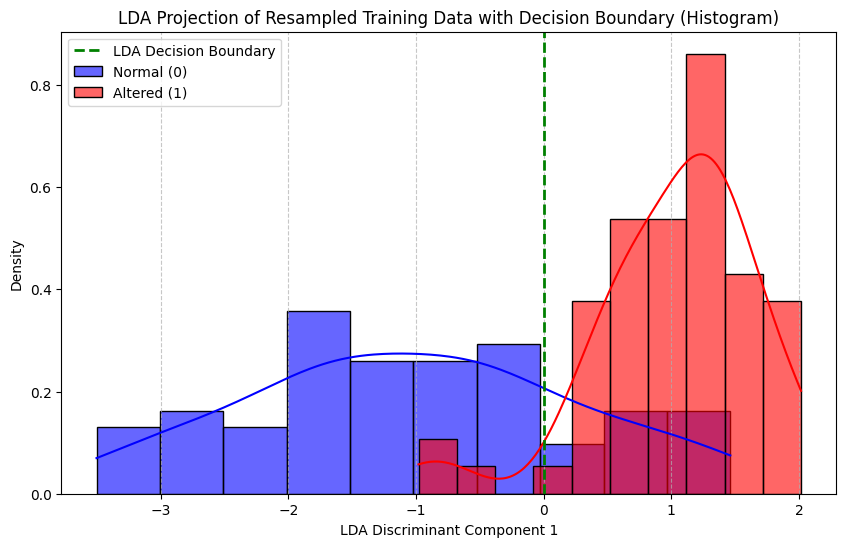

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Transform the resampled training data to the LDA's single discriminant space
X_train_lda_proj = lda.transform(X_train_resampled)

plt.figure(figsize=(10, 6))

# Plot histogram for class 0 (Normal) in training data
sns.histplot(x=X_train_lda_proj[y_train_resampled == 0].flatten(), color='blue', label='Normal (0)', kde=True, stat='density', alpha=0.6, bins=10)

# Plot histogram for class 1 (Altered) in training data
sns.histplot(x=X_train_lda_proj[y_train_resampled == 1].flatten(), color='red', label='Altered (1)', kde=True, stat='density', alpha=0.6, bins=10)

# Add the vertical decision boundary line (calculated earlier from the fitted model)
plt.axvline(x=decision_boundary_lda, color='green', linestyle='--', linewidth=2, label='LDA Decision Boundary')

plt.title('LDA Projection of Resampled Training Data with Decision Boundary (Histogram)')
plt.xlabel('LDA Discriminant Component 1')
plt.ylabel('Density')
plt.legend()
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.show()

Pasando al gráfico, el eje `x` representa la componente de la discriminante creada por el modelo LDA. El eje `y` indica la concentración de los puntos a lo largo de diferentes valores de la componente de la discriminante. Los datos en color azul representan la clase "Normal", mientras que los datos de color rojo representan la clase "Alterada". Idealmente, cada una de estas clases debería estar en un lado diferente del límite de decisión (la línea punteada verde). Sin embargo, en una situación real como esta es muy poco probable que suceda esto. Aunque sí se puede ver una tendencia en qué lado toma cada clase, sí existe una superposición entre clases. Esto indica que no hay una separación tan clara entre clases, indicando que el modelo puede cometer errores a la hora de clasificar las muestras.


Ahora, se evaluará el desempeño del modelo usando los datos de `test`. Para esto, se crearán predicciones para `y`, usando los datos de `X_test_resampled` y comparándolos con los valores reales de `y`. Posteriormente se calculan y muestran las métricas necesarias para evaluar el modelo. Además, se incluye una matriz de confusión más clara para visualizar el desempeño del modelo.
Se usan las mismas fórmulas ya empleadas en el reporte para estos mismo procedimientos.









In [ ]:
# Make predictions on the test set
y_pred_lda_test = lda.predict(X_test)

# Evaluate the model on the test data
print("Linear Discriminant Analysis Model Evaluation on Test Data:")
print("Accuracy:", accuracy_score(y_test, y_pred_lda_test))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lda_test))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lda_test))

Linear Discriminant Analysis Model Evaluation on Test Data:
Accuracy: 0.6

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.65      0.74        26
           1       0.10      0.25      0.14         4

    accuracy                           0.60        30
   macro avg       0.47      0.45      0.44        30
weighted avg       0.75      0.60      0.66        30


Confusion Matrix:
 [[17  9]
 [ 3  1]]


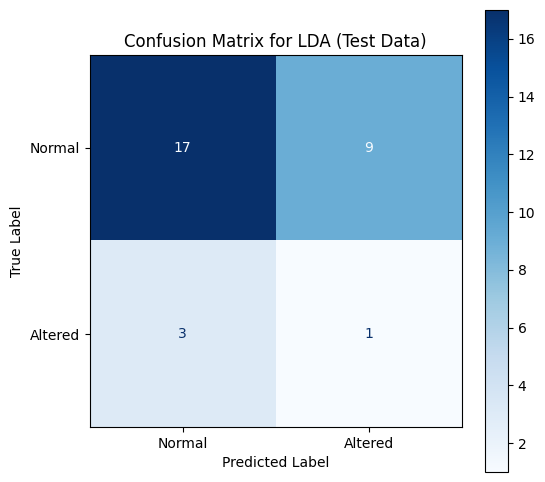

In [ ]:
# Define the labels for the classes
class_labels = ['Normal', 'Altered']

# Create the confusion matrix display with values inside the cells for the test set
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lda_test, display_labels=class_labels, cmap=plt.cm.Blues, ax=ax, values_format='d')

# Add titles and labels for clarity
ax.set_title('Confusion Matrix for LDA (Test Data)')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')

plt.grid(False) # Turn off grid for confusion matrix
plt.show()

#### **Métricas del modelo en prueba**
* **Acuracy**: 60% de las predicciones totales fueron correctas.
* **Precision** (clase 0 "Normal"): 85% de las veces que el modelo predijo que la muestra estaba normal en realidad sí estaba normal
* **Recall** (clase 0 "Normal"): 65%, el modelo logró captar este porcentaje del 100% de las muestras del conjunto que sí estaban normales.
* **F1-score** (clase 0 "Normal"): 74%, promedio armónico entre **precision** y **accuracy** de esta clase.
* **Precision** (clase 1 "Alterada"): 10% de las veces que el modelo predijo que la muestra estaba alterada en realidad sí estaba alterada
* **Recall** (clase 1 "Alterada"): 25%, el modelo logró captar este porcentaje del 100% de las muestras del conjunto que sí estaban alteradas.
* **F1-score** (clase 1 "Alterada"): 14%, promedio armónico entre **precision** y **accuracy** de esta clase.


Este modelo muestra un peor rendimiento que el modelo de *Regresión Logística*, aunque sólo por unos puntos. De nuevo, el modelo sólo logró predecir como "Alterado" a 1 sola muestra de las 4 presentes en el conjunto de `test`, como se puede ver en la matriz de confusión. A pesar de que parecía ser un buen modelo con los datos de entrenamiento, ya que se probó con datos que el modelo no había visto tuvo problemas identificando la clase "Alterada", aunque no tuvo un desempeño tan malo con la clase "Normal".











#### **3. Random Forest**


Ahora, se entrenará un modelo Random Forest.
Para comenzar, se importa la librería `RandomForestClassifier`, necesaria para hacer el modelo.


Para optimizar el rendimiento del modelo Random Forest, se realizará una búsqueda de hiperparámetros utilizando `GridSearchCV`. Esto explorará diferentes combinaciones de `n_estimators` (número de árboles), `max_depth` (profundidad máxima del árbol), `min_samples_split` (mínimo de muestras para dividir un nodo) y `min_samples_leaf` (mínimo de muestras en una hoja), para encontrar la configuración que proporcione el mejor rendimiento. (GeeksforGeeks, 2025)


Se establece una variable `param_grid` con diferentes valores a probar para cada uno de los parámetros mencionados. A la función `GridSearchCV` se le ponen como parámetros el modelo creado, los valores de alpha encontrados anteriormente, `cv=5`, que indica la validación cruzada de 5 *folds* (entrena con 4, valida con 1) y el criterio para elegir los hiperparámetros que creen el mejor modelo (`scoring='f1_macro'`, ya que da una perspectiva de cómo se comportó el modelo en ambas clases), El modelo luego se ajusta con `grid_search.fit()` utilizando los datos de entrenamiento previamente balanceados. Por último, se identifican los mejores hiperparámetros y el mejor desempeño promedio con `.best_params_` y `best_score_` respectivamente. Finalmente se selecciona el modelo con mejor desempeño con `best_estimator_`, en el cuál se usarán los datos de entrenamiento y prueba para ver su desempeño.





In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Define the parameter grid for Random Forest
param_grid = {
    'n_estimators': [50, 100, 150, 200], # Number of trees in the forest
    'max_depth': [None, 10, 20, 30],      # Maximum depth of the tree
    'min_samples_split': [2, 5, 10],      # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4]         # Minimum number of samples required to be at a leaf node
}

# Initialize a Random Forest Classifier with balanced class weights for imbalanced datasets
# Although SMOTE has been applied, balanced weights can still be beneficial.
rf_base = RandomForestClassifier(random_state=42, class_weight='balanced')

# Initialize GridSearchCV
# cv=5 for 5-fold cross-validation
# scoring='f1_macro' is a good metric for imbalanced classification
grid_search_rf = GridSearchCV(estimator=rf_base, param_grid=param_grid, cv=5, scoring='f1_macro', n_jobs=-1, verbose=1)

# Fit GridSearchCV to the resampled training data
print("Starting GridSearchCV for Random Forest...")
grid_search_rf.fit(X_train_resampled, y_train_resampled)
print("GridSearchCV for Random Forest completed.")

# Print the best parameters and best score
print("\nBest parameters found:", grid_search_rf.best_params_)
print("Best F1-macro score achieved:", grid_search_rf.best_score_)

# Get the best model
rf_optimized = grid_search_rf.best_estimator_

Starting GridSearchCV for Random Forest...
Fitting 5 folds for each of 144 candidates, totalling 720 fits
GridSearchCV for Random Forest completed.

Best parameters found: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Best F1-macro score achieved: 0.900621054552089


Se puede observar que los mejores hiperparámetros encontrados fueron los siguientes:
- `max_depth`: None
- `min_sample_leaf`: 1
- `min_sample_split`: 5
- `n_estimators`: 100

Y el mejor `f1-score` obtenido fue de 90%.

Ahora, se evaluará este modelo en los datos de entrenamiento, de la misma manera y con las mismas funciones que en los modelos anteriores.

In [ ]:
# Make predictions on the resampled training set with the optimized model
y_pred_rf_opt_train = rf_optimized.predict(X_train_resampled)

# Evaluate the optimized model on the resampled training data
print("Random Forest Optimized Model Evaluation on Resampled Training Data:")
print("Accuracy:", accuracy_score(y_train_resampled, y_pred_rf_opt_train))
print("\nClassification Report:\n", classification_report(y_train_resampled, y_pred_rf_opt_train))
print("\nConfusion Matrix:\n", confusion_matrix(y_train_resampled, y_pred_rf_opt_train))


Random Forest Optimized Model Evaluation on Resampled Training Data:
Accuracy: 0.9838709677419355

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98        62
           1       1.00      0.97      0.98        62

    accuracy                           0.98       124
   macro avg       0.98      0.98      0.98       124
weighted avg       0.98      0.98      0.98       124


Confusion Matrix:
 [[62  0]
 [ 2 60]]


#### **Métricas del modelo en entrenamiento**
* **Acuracy**: 98.39% de las predicciones totales fueron correctas.
* **Precision** (clase 0 "Normal"): 97% de las veces que el modelo predijo que la muestra estaba normal en realidad sí estaba normal
* **Recall** (clase 0 "Normal"): 100%, el modelo logró captar este porcentaje del 100% de las muestras del conjunto que sí estaban normales.
* **F1-score** (clase 0 "Normal"): 98%, promedio armónico entre **precision** y **accuracy** de esta clase.
* **Precision** (clase 1 "Alterada"): 100% de las veces que el modelo predijo que la muestra estaba alterada en realidad sí estaba alterada
* **Recall** (clase 1 "Alterada"): 97%, el modelo logró captar este porcentaje del 100% de las muestras del conjunto que sí estaban alteradas.
* **F1-score** (clase 1 "Alterada"): 98%, promedio armónico entre **precision** y **accuracy** de esta clase.


Hasta ahora, este modelo en entrenamiento ha sido el que tiene mejores métricas. Parece ser muy bueno distinguiendo entre clases, cometiendo muy pocos errores. Sólo 2 veces marcó como "Normal" muestras que realmente estaban alteradas. Sin embargo, este gran desempeño puede deber a un sobreajuste, por lo que es importante ahora evaluarlo en los datos de prueba.




A continuación se imprimen las "importancias" de cada variable en el modelo, con la función `.features_importances_`.













In [ ]:
import pandas as pd

# Get feature importances from the optimized Random Forest model
feature_importances = rf_optimized.feature_importances_

# Get the feature names
feature_names = X.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Sort the features by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Feature Importances for Optimized Random Forest Model:")
display(importance_df)

Feature Importances for Optimized Random Forest Model:


,Feature,Importance
0,Season,0.325941
8,Number of hours spent sitting per day,0.188730
6,Frequency of alcohol consumption,0.146865
1,Age,0.117977
3,Accident or serious trauma,0.107241
5,High fevers in the last year,0.054632
7,Smoking habit,0.031703
4,Surgical intervention,0.018758
2,Childish diseases,0.008153






Se puede observar que las variables con mayor importancia son `Season`, `Number of hours sitting per day` y `Frequency of alcohol consumption`. Por el contrario, las variables que tienen menos peso en este modelo son `Surgical intervention` y `Childish diseases`.


Ahora, se hacen las predicciones para `y` usando los datos de `X` del conjunto de datos para prueba y se calculan las métricas necesarias para la evaluación, así como se ha hecho con los modelos previos, además de mostrar la matriz de confusión en un heatmap y con nombres en los ejes para mayor facilidad de comprensión.





Random Forest Optimized Model Evaluation on Test Data:
Accuracy: 0.8

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.88      0.88        26
           1       0.25      0.25      0.25         4

    accuracy                           0.80        30
   macro avg       0.57      0.57      0.57        30
weighted avg       0.80      0.80      0.80        30


Confusion Matrix:
 [[23  3]
 [ 3  1]]


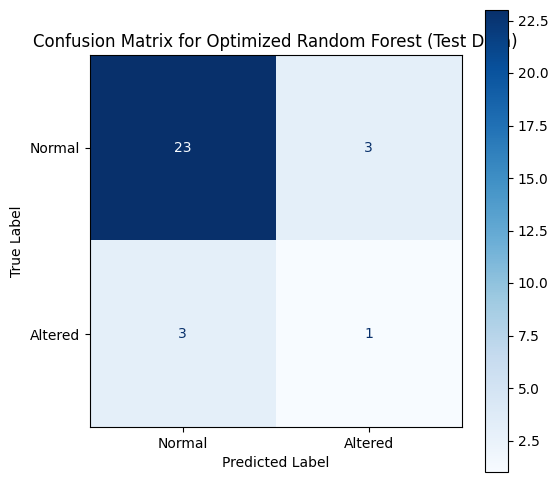

In [ ]:
# Make predictions on the test set with the optimized model
y_pred_rf_opt_test = rf_optimized.predict(X_test)

# Evaluate the optimized model on the test data
print("Random Forest Optimized Model Evaluation on Test Data:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf_opt_test))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf_opt_test))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf_opt_test))

# Plot Confusion Matrix for optimized RF on test data
class_labels = ['Normal', 'Altered']
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf_opt_test, display_labels=class_labels, cmap=plt.cm.Blues, ax=ax, values_format='d')
ax.set_title('Confusion Matrix for Optimized Random Forest (Test Data)')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.grid(False)
plt.show()

#### **Métricas del modelo en prueba**
* **Acuracy**: 80% de las predicciones totales fueron correctas.
* **Precision** (clase 0 "Normal"): 88% de las veces que el modelo predijo que la muestra estaba normal en realidad sí estaba normal
* **Recall** (clase 0 "Normal"): 88%, el modelo logró captar este porcentaje del 100% de las muestras del conjunto que sí estaban normales.
* **F1-score** (clase 0 "Normal"): 88%, promedio armónico entre **precision** y **accuracy** de esta clase.
* **Precision** (clase 1 "Alterada"): 25% de las veces que el modelo predijo que la muestra estaba alterada en realidad sí estaba alterada
* **Recall** (clase 1 "Alterada"): 25%, el modelo logró captar este porcentaje del 100% de las muestras del conjunto que sí estaban alteradas.
* **F1-score** (clase 1 "Alterada"): 25%, promedio armónico entre **precision** y **accuracy** de esta clase.




Hasta ahora, este ha sido el mejor modelo de los 3. Ahora, se tiene una exactitud del 80%. Y este modelo es mejor para predecir la clase "Normal", fallando sólo en 3 muestras. Sin embargo, para predecir la clase "Alterada" sólo predijo correctamente 1 de 4 muestras, al igual que los otros modelos. Y para el propósito de este reporte, es realmente importante que se prediga correctamente las muestras que están alteradas, debido a que se busca que las personas puedan detectar infertilidad y poder actuar al respecto sin tener que hacerse estudios costosos, además de poder facilitar la detección de posibles personas infértiles en bancos de esperma.





#### **4. Support Vector Machines (SVM)**
Para el modelo Support Vector Machines (SVM) se importa la librería `SVC`. Al igual que se hizo con el modelo anterior, se hará una búsqueda de la mejor combinación de hiperparámetros que generen el mejor modelo. Para esto, se usa el mismo método empleado anteriormente, sólo que ahora los parámetros a optimizar son `C` (parámetro de regularización), `kernel` (función usada para separar las clases) y `gamma` (cuánto influye un único punto de entrenamiento) (GeeksforGeeks, 2025).


Ya que se obtienen los mejores parámetros, se guarda el modelo optimizado y se hacen predicciones para los datos de entrenamiento para poder calcular las métricas necesarias para evaluar el modelo. Para esto se siguen los mismos pasos y se usan las mismas funciones anteriormente usadas en los otros modelos.





In [ ]:
from sklearn.svm import SVC

# Define the parameter grid for SVM
param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto', 0.1, 1] # 'gamma' is relevant for 'rbf' kernel
}

# Initialize a Support Vector Classifier with balanced class weights
svm_base = SVC(random_state=42, class_weight='balanced')

# Initialize GridSearchCV
# cv=5 for 5-fold cross-validation
# scoring='f1_macro' is a good metric for imbalanced classification
grid_search_svm = GridSearchCV(estimator=svm_base, param_grid=param_grid_svm, cv=5, scoring='f1_macro', n_jobs=-1, verbose=1)

# Fit GridSearchCV to the resampled training data
print("Starting GridSearchCV for SVM...")
grid_search_svm.fit(X_train_resampled, y_train_resampled)
print("GridSearchCV for SVM completed.")

# Print the best parameters and best score
print("\nBest parameters found:", grid_search_svm.best_params_)
print("Best F1-macro score achieved:", grid_search_svm.best_score_)

# Get the best model
svm_optimized = grid_search_svm.best_estimator_

# Make predictions on the resampled training set with the optimized model
y_pred_svm_train = svm_optimized.predict(X_train_resampled)

# Evaluate the model on the resampled training data
print("\nSupport Vector Machine Optimized Model Evaluation on Resampled Training Data:")
print("Accuracy:", accuracy_score(y_train_resampled, y_pred_svm_train))
print("\nClassification Report:\n", classification_report(y_train_resampled, y_pred_svm_train))
print("\nConfusion Matrix:\n", confusion_matrix(y_train_resampled, y_pred_svm_train))

Starting GridSearchCV for SVM...
Fitting 5 folds for each of 32 candidates, totalling 160 fits
GridSearchCV for SVM completed.

Best parameters found: {'C': 100, 'gamma': 1, 'kernel': 'rbf'}
Best F1-macro score achieved: 0.926931734931735

Support Vector Machine Optimized Model Evaluation on Resampled Training Data:
Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        62
           1       1.00      1.00      1.00        62

    accuracy                           1.00       124
   macro avg       1.00      1.00      1.00       124
weighted avg       1.00      1.00      1.00       124


Confusion Matrix:
 [[62  0]
 [ 0 62]]


#### **Métricas del modelo en entrenamiento**
* **Acuracy**: 100% de las predicciones totales fueron correctas.
* **Precision** (clase 0 "Normal"): 100% de las veces que el modelo predijo que la muestra estaba normal en realidad sí estaba normal
* **Recall** (clase 0 "Normal"): 100%, el modelo logró captar este porcentaje del 100% de las muestras del conjunto que sí estaban normales.
* **F1-score** (clase 0 "Normal"): 100%, promedio armónico entre **precision** y **accuracy** de esta clase.
* **Precision** (clase 1 "Alterada"): 100% de las veces que el modelo predijo que la muestra estaba alterada en realidad sí estaba alterada
* **Recall** (clase 1 "Alterada"): 100%, el modelo logró captar este porcentaje del 100% de las muestras del conjunto que sí estaban alteradas.
* **F1-score** (clase 1 "Alterada"): 100%, promedio armónico entre **precision** y **accuracy** de esta clase.


Hasta el momento, este ha sido el único momento con un desempeño perfecto en entrenamiento. Sin embargo, esto podría deberse a sobreajuste, por lo cual es importante revisar estas mismas métricas con datos que el modelo no ha visto aun.


Para eso, se crean predicciones para `y`, usando los valores de `X_test` y comparándolos con los valores reales de `y`. Se usan las mismas funciones ya mencionadas y se muestran para su evaluación. Además, se imprime la matriz de confusión de una manera más comprensible, así como se ha estado haciendo para todas las matrices de confusión en el conjunto de datos de prueba.





In [ ]:
# Make predictions on the test set with the optimized model
y_pred_svm_test = svm_optimized.predict(X_test)

# Evaluate the model on the test data
print("Support Vector Machine Optimized Model Evaluation on Test Data:")
print("Accuracy:", accuracy_score(y_test, y_pred_svm_test))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm_test))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_svm_test))

Support Vector Machine Optimized Model Evaluation on Test Data:
Accuracy: 0.6333333333333333

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.69      0.77        26
           1       0.11      0.25      0.15         4

    accuracy                           0.63        30
   macro avg       0.48      0.47      0.46        30
weighted avg       0.76      0.63      0.68        30


Confusion Matrix:
 [[18  8]
 [ 3  1]]


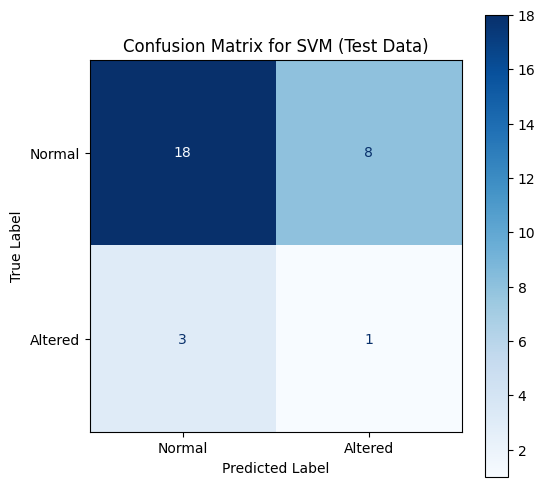

In [ ]:
# Define the labels for the classes
class_labels = ['Normal', 'Altered']

# Create the confusion matrix display with values inside the cells for the test set
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_svm_test, display_labels=class_labels, cmap=plt.cm.Blues, ax=ax, values_format='d')

# Add titles and labels for clarity
ax.set_title('Confusion Matrix for SVM (Test Data)')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')

plt.grid(False) # Turn off grid for confusion matrix
plt.show()

#### **Métricas del modelo en prueba**
* **Acuracy**: 63% de las predicciones totales fueron correctas.
* **Precision** (clase 0 "Normal"): 86% de las veces que el modelo predijo que la muestra estaba normal en realidad sí estaba normal
* **Recall** (clase 0 "Normal"): 69%, el modelo logró captar este porcentaje del 100% de las muestras del conjunto que sí estaban normales.
* **F1-score** (clase 0 "Normal"): 77%, promedio armónico entre **precision** y **accuracy** de esta clase.
* **Precision** (clase 1 "Alterada"): 11% de las veces que el modelo predijo que la muestra estaba alterada en realidad sí estaba alterada
* **Recall** (clase 1 "Alterada"): 25%, el modelo logró captar este porcentaje del 100% de las muestras del conjunto que sí estaban alteradas.
* **F1-score** (clase 1 "Alterada"): 15%, promedio armónico entre **precision** y **accuracy** de esta clase.


Con los datos de prueba, el modelo ya no se comporta tan perfecto como parecía ser. Todas las métricas decrementaron significativamente, lo que puedo indicar que sí puede haber un posible *overfitting*. De nuevo, de la clase "Alterada", sólo logró predecir 1 de 4 muestras presentes. Aunque el modelo parece ser mejor identificando las muestras normales, sólo logró identificar menos del 70% de ellas.





#### **5. Redes neuronales**
Para el modelo de Redes Neuronales se instala `keras-tuner`, para poder optimizar los hiperparámetros del modelo. Después, se importan las librerías `tf`, `keras` y `RandomSearch`, donde las primeras dos servirán para crear el modelo y la tercera será el método usado para encontrar los mejores hiperparámetros, debido a la capacidad computacional con la que se cuenta.


Se buscan optimizar parámetros como `num_layers`(número de capas ocultas), `units_i` (número de neuronas por capa). También se optimiza la función de activación, y `dropout_i` (porcentaje de neuronas que se desactivan durante el entrenamiento para evitar sobreajuste). De igual manera, se ajusta la tasa de aprendizaje `learning rate` para determinar qué tan rápido debe aprender el modelo.


Posteriormente, se escalan los datos usando `StandardScaler`, previamente importando la librería con el mismo nombre. Después, el `tuner` ejecuta una búsqueda aleatoria probando diferentes combinaciones de parámetros, con un máximo de 10 combinaciones, entrenando cada configuración dos veces para reducir la variabilidad. Al igual que en los otros modelos donde se hizo una optimización de hiperparámetros, se establece el `f1-score` como criterio de evaluación del modelo, para poder encontrar el mejor equilibrio entre precisión y recall. Por último, se imprimen los mejor hiperparámetros encontrados. (GeeksforGeeks, 2025)







In [ ]:
pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 5.9 MB/s eta 0:00:00


In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras_tuner import RandomSearch

In [ ]:
import random

# Set global seed for reproducibility
seed_value = 42
np.random.seed(seed_value)
tf.random.set_seed(seed_value)
random.seed(seed_value)

# If you are running on a GPU, these two lines can help ensure determinism,
# but might have a performance impact.
# tf.config.experimental.set_visible_devices([], 'GPU')
# os.environ['TF_DETERMINISTIC_OPS'] = '1'

print(f"Global random seed set to: {seed_value}")

Global random seed set to: 42


In [ ]:
# Define a function to build the Keras model for hyperparameter tuning
def build_model(hp):
    nn_model = keras.Sequential()
    nn_model.add(keras.layers.InputLayer(input_shape=(X_train_resampled_scaled.shape[1],))) # Use scaled data input shape

    # Tune the number of hidden layers
    for i in range(hp.Int('num_layers', 1, 3)):
        nn_model.add(keras.layers.Dense(
            units=hp.Int(f'units_{i}', min_value=32, max_value=512, step=32),
            activation=hp.Choice('activation', ['relu', 'tanh'])
        )) # Using relu/tanh for hidden layers
        nn_model.add(keras.layers.Dropout(hp.Float(f'dropout_{i}', 0.0, 0.5, step=0.1)))

    nn_model.add(keras.layers.Dense(1, activation='sigmoid')) # Output layer for binary classification

    # Tune the learning rate for the optimizer
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])

    nn_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=hp_learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.F1Score(threshold=0.5)] # Keep F1Score objective
    )
    return nn_model

In [ ]:
from sklearn.preprocessing import StandardScaler

# Scale the data for Neural Network
scaler = StandardScaler()
X_train_resampled_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)

# Initialize the Keras Tuner (RandomSearch in this case)
tuner = RandomSearch(
    build_model,
    objective='val_f1_score', # Keep objective as val_f1_score
    max_trials=10, # Number of different hyperparameter combinations to try
    executions_per_trial=2, # Number of models to train for each trial (to reduce variance)
    directory='my_dir',
    project_name='fertility_diagnosis_nn_rescaled' # New project name to avoid conflicts
)

# Display a summary of the search space
tuner.search_space_summary()

Reloading Tuner from my_dir/fertility_diagnosis_nn_rescaled/tuner0.json
Search space summary
Default search space size: 9
num_layers (Int)
{'default': None, 'conditions': [], 'min_value': 1, 'max_value': 3, 'step': 1, 'sampling': 'linear'}
units_0 (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 512, 'step': 32, 'sampling': 'linear'}
activation (Choice)
{'default': 'relu', 'conditions': [], 'values': ['relu', 'tanh'], 'ordered': False}
dropout_0 (Float)
{'default': 0.0, 'conditions': [], 'min_value': 0.0, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
learning_rate (Choice)
{'default': 0.01, 'conditions': [], 'values': [0.01, 0.001, 0.0001], 'ordered': True}
units_1 (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 512, 'step': 32, 'sampling': 'linear'}
dropout_1 (Float)
{'default': 0.0, 'conditions': [], 'min_value': 0.0, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
units_2 (Int)
{'default': None, 'conditions': [], 'min_value'

In [ ]:
# Run the hyperparameter search using scaled data
tuner.search(
    X_train_resampled_scaled, y_train_resampled,
    epochs=20,
    validation_data=(X_test_scaled, y_test),
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)]
)

# Get the optimal hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"The best hyperparameters found are: {best_hps.values}")

The best hyperparameters found are: {'num_layers': 3, 'units_0': 512, 'activation': 'relu', 'dropout_0': 0.0, 'learning_rate': 0.001, 'units_1': 288, 'dropout_1': 0.0, 'units_2': 32, 'dropout_2': 0.0}


Los mejores hipermarámetros que se encontraron fueron los siguientes:
- `num_layers`: 3
- `units_0`: 512
- `activation`: relu
- `dropout_0`: 0
- `learning_rate`: 0.001
- `units_1`: 288
- `dropout_1`: 0.0
- `units_2`: 32
- `dropout_2`: 0.0

Ahora, se entrenará el modelo usando estos hiperparámetros y el conjunto de datos de entrenamiento. Posteriormente se calculan las mismas métricas que se han calculado para los otros modelo, primero creando las predicciones para `y`.

In [ ]:
# Build the best model with the optimal hyperparameters
nn_optimized = tuner.get_best_models(num_models=1)[0]

# Evaluate the optimized model on the scaled resampled training data
print("Neural Network Optimized Model Evaluation on Training Data:")
train_metrics = nn_optimized.evaluate(X_train_resampled_scaled, y_train_resampled, verbose=0)
train_loss, train_accuracy, train_f1_score = train_metrics[0], train_metrics[1], train_metrics[2]


y_train_pred_proba = nn_optimized.predict(X_train_resampled_scaled, verbose=0)
y_train_pred_nn = (y_train_pred_proba > 0.5).astype(int)

print("\nTraining Classification Report:")
print(classification_report(y_train_resampled, y_train_pred_nn))

print("\nTraining Confusion Matrix:")
print(confusion_matrix(y_train_resampled, y_train_pred_nn))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Neural Network Optimized Model Evaluation on Training Data:

Training Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87        62
           1       0.89      0.82      0.86        62

    accuracy                           0.86       124
   macro avg       0.87      0.86      0.86       124
weighted avg       0.87      0.86      0.86       124


Training Confusion Matrix:
[[56  6]
 [11 51]]


#### **Métricas del modelo en entrenamiento**
* **Acuracy**: 86% de las predicciones totales fueron correctas.
* **Precision** (clase 0 "Normal"): 84% de las veces que el modelo predijo que la muestra estaba normal en realidad sí estaba normal
* **Recall** (clase 0 "Normal"): 90%, el modelo logró captar este porcentaje del 100% de las muestras del conjunto que sí estaban normales.
* **F1-score** (clase 0 "Normal"): 87%, promedio armónico entre **precision** y **accuracy** de esta clase.
* **Precision** (clase 1 "Alterada"): 89% de las veces que el modelo predijo que la muestra estaba alterada en realidad sí estaba alterada
* **Recall** (clase 1 "Alterada"): 82%, el modelo logró captar este porcentaje del 100% de las muestras del conjunto que sí estaban alteradas.
* **F1-score** (clase 1 "Alterada"): 86%, promedio armónico entre **precision** y **accuracy** de esta clase.


El modelo parecería ser moderadamente bueno distinguiendo entre clases, con métricas por arriba del 80%, son los datos de entrenamiento. Este comportamiento es muy similar en comparación con los otros modelos en la parte de entrenamiento.


Ahora, es momento de ponerlo a prueba. Para eso, se usarán los datos de `X` de prueba para crear predicciones para `y` y posteriormente compararlas con los valores reales de esta variable del conjunto `test`. De igual manera, se imprimen las métricas necesarias para evaluar al modelo. Además, se agrega la matriz de confusión con un heatmap para una mejor visualización.







In [ ]:
# Evaluate the best model on the scaled test data
print("\nNeural Network Optimized Model Evaluation on Test Data:")
test_metrics = nn_optimized.evaluate(X_test_scaled, y_test, verbose=0)
test_loss, test_accuracy, test_f1_score = test_metrics[0], test_metrics[1], test_metrics[2]


y_test_pred_proba_nn = nn_optimized.predict(X_test_scaled, verbose=0)
y_test_pred_nn = (y_test_pred_proba_nn > 0.5).astype(int)

print("\nTest Classification Report:")
print(classification_report(y_test, y_test_pred_nn))

print("\nTest Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_nn))


Neural Network Optimized Model Evaluation on Test Data:

Test Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.88      0.87        26
           1       0.00      0.00      0.00         4

    accuracy                           0.77        30
   macro avg       0.43      0.44      0.43        30
weighted avg       0.74      0.77      0.75        30


Test Confusion Matrix:
[[23  3]
 [ 4  0]]


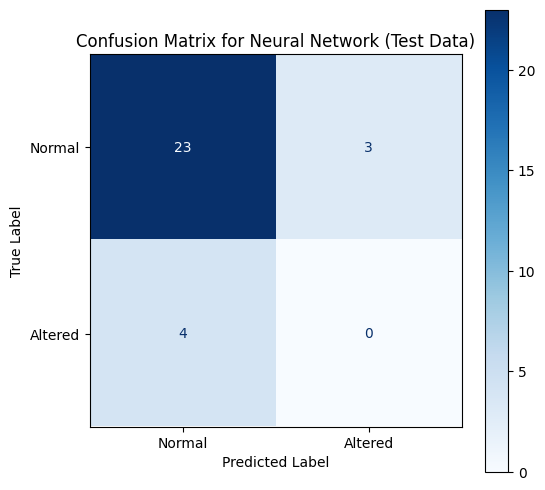

In [ ]:
# Define the labels for the classes
class_labels = ['Normal', 'Altered']

# Create the confusion matrix display with values inside the cells for the test set
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred_nn, display_labels=class_labels, cmap=plt.cm.Blues, ax=ax, values_format='d')

# Add titles and labels for clarity
ax.set_title('Confusion Matrix for Neural Network (Test Data)')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')

plt.grid(False) # Turn off grid for confusion matrix
plt.show()

#### **Métricas del modelo en prueba**
* **Acuracy**: 77% de las predicciones totales fueron correctas.
* **Precision** (clase 0 "Normal"): 85% de las veces que el modelo predijo que la muestra estaba normal en realidad sí estaba normal
* **Recall** (clase 0 "Normal"): 88%, el modelo logró captar este porcentaje del 100% de las muestras del conjunto que sí estaban normales.
* **F1-score** (clase 0 "Normal"): 87%, promedio armónico entre **precision** y **accuracy** de esta clase.
* **Precision** (clase 1 "Alterada"): 0% de las veces que el modelo predijo que la muestra estaba alterada en realidad sí estaba alterada
* **Recall** (clase 1 "Alterada"): 0%, el modelo logró captar este porcentaje del 100% de las muestras del conjunto que sí estaban alteradas.
* **F1-score** (clase 1 "Alterada"): 0%, promedio armónico entre **precision** y **accuracy** de esta clase.


Aunque este modelo no tiene el peor valor en exactitud, fue el único modelo que no pudo identificar ninguna de las muestras alteradas. Aunque sí parece ser bueno identificando la clase "Normal", este modelo no parecería ser una buena opción para identificar los casos alterados.











---


####**Comparación de todos los modelos**

A continuación, se creará una tabla comparativa mostrando todas las métricas relevantes por cada modelo, al igual que la diferencia entre la diferencia de exactitud del modelo entre los datos de prueba y de entrenamiento. Se utilizaron los datos de la clase relevante al problema, la clase 1 "Alterada".


In [ ]:
import pandas as pd

# Metrics for Logistic Regression
log_reg_metrics = {
    'Model': 'Logistic Regression',
    'Train Accuracy': 0.8467741935483871,
    'Test Accuracy': 0.6333333333333333,
    'Test Precision (Class 1)': 0.11,
    'Test Recall (Class 1)': 0.25,
    'Test F1-score (Class 1)': 0.15
}

# Metrics for LDA
lda_metrics = {
    'Model': 'Linear Discriminant Analysis (LDA)',
    'Train Accuracy': 0.8709677419354839,
    'Test Accuracy': 0.6,
    'Test Precision (Class 1)': 0.10,
    'Test Recall (Class 1)': 0.25,
    'Test F1-score (Class 1)': 0.14
}

# Metrics for Random Forest (Optimized)
rf_metrics = {
    'Model': 'Random Forest (Optimized)',
    'Train Accuracy': 0.9838709677419355,
    'Test Accuracy': 0.8,
    'Test Precision (Class 1)': 0.25,
    'Test Recall (Class 1)': 0.25,
    'Test F1-score (Class 1)': 0.25
}

# Metrics for SVM (Optimized)
svm_metrics = {
    'Model': 'Support Vector Machine (Optimized)',
    'Train Accuracy': 1.0,
    'Test Accuracy': 0.6333333333333333,
    'Test Precision (Class 1)': 0.11,
    'Test Recall (Class 1)': 0.25,
    'Test F1-score (Class 1)': 0.15
}

# Metrics for Neural Network (Optimized)
mlp_metrics = {
    'Model': 'Neural Network (Optimized)',
    'Train Accuracy': 0.8629032373428345,
    'Test Accuracy': 0.7666666507720947,
    'Test Precision (Class 1)': 0.00,
    'Test Recall (Class 1)': 0.00,
    'Test F1-score (Class 1)': 0.00
}

# Create a DataFrame from the metrics
comparison_df = pd.DataFrame([
    log_reg_metrics,
    lda_metrics,
    rf_metrics,
    svm_metrics,
    mlp_metrics
])

# Calculate the difference in accuracy between train and test sets
comparison_df['Accuracy Difference (Train - Test)'] = comparison_df['Train Accuracy'] - comparison_df['Test Accuracy']

# Sort by Test Accuracy for better comparison
comparison_df = comparison_df.sort_values(by='Test Accuracy', ascending=False).reset_index(drop=True)

display(comparison_df.round(3))

,Model,Train Accuracy,Test Accuracy,Test Precision (Class 1),Test Recall (Class 1),Test F1-score (Class 1),Accuracy Difference (Train - Test)
0,Random Forest (Optimized),0.984,0.800,0.25,0.25,0.25,0.184
1,Neural Network (Optimized),0.863,0.767,0.00,0.00,0.00,0.096
2,Logistic Regression,0.847,0.633,0.11,0.25,0.15,0.213
3,Support Vector Machine (Optimized),1.000,0.633,0.11,0.25,0.15,0.367
4,Linear Discriminant Analysis (LDA),0.871,0.600,0.10,0.25,0.14,0.271


**Puntos importantes a partir de la tabla:**


* **Rendimiento General** (Test Accuracy): El modelo de Random Forest obtuvo la mayor exactitud en el conjunto de prueba (0.800), seguido por la Red Neuronal (0.767). Los modelos de Regresión Logística y SVM tuvieron un rendimiento similar (0.633), mientras que LDA fue el que obtuvo la menor precisión (0.600).


* **Detección de la Clase Minoritaria** ('Alterado'): Este es el aspecto más relevante del problema, debido a lo que se ha planteado a lo largo del reporte. Todos los modelos muestran un recall muy bajo para la clase 'Alterado' (0.250 o 0.000), lo que significa que solo lograron identificar 1 de las 4 muestras realmente alteradas en el conjunto de prueba, o ninguna en el caso de la Red Neuronal. La precisión para la clase 'Alterado' también es consistentemente baja, siendo ligeramente mejor en Random Forest (0.250) que en los demás.


* **F1-score** (Clase 'Alterado'): El f1-score, que es una media armónica de precisión y recall, confirma el mal desempeño en la identificación de la clase 'Alterado' para todos los modelos. El Random Forest presenta el valor más alto (0.250), aunque aún es muy bajo. La Red Neuronal obtiene un F1-score de 0.00 para la clase alterada..


* **Diferencia de Precisión** (Train - Test): Esta métrica indica el grado de sobreajuste del modelo:


  * SVM (0.367) y Random Forest (0.184) muestran las mayores diferencias, lo que indica que puede haber un sobreajuste significativo, especialmente en SVM que lograba un 100% de precisión en entrenamiento.
  * Logistic Regression (0.213) y LDA (0.271) tienen diferencias de precisión más pequeñas, lo que implica un menor sobreajuste, pero también un rendimiento bajo en general.
  * La Red Neuronal tiene una diferencia moderada (0.096).


Se decide elegir el modelo de Random Forest, debido a que es el que tuvo las mejores métricas para la clase 1 en `train`, además de la mayor exactitud. Además, es un modelo relativamente interpretable gracias a la "importancia" que se le da a cada variable, así como se pudo ver en la construcción y análisis del modelo. Esto es algo muy importante, ya que se estará tratando con pacientes que posiblemente estén buscando la creación de una familia y teniendo en cuenta qué factores afectan más para mantener las muestras "Normales" podría ayudarlos a mejorar sus hábitos en estos aspectos.


No obstante, es importante recalcar que todos los modelos muestran un bajo desempeño a la hora de encontrar las muestras alteradas, lo que podría deberse al desbalance en las clases, pocos datos o que los datos de la clase 1 en el conjunto de `test` sean algo atípicos y por eso los modelos están batallando en encontrarlos.


Recordando que se obtuvo la siguiente tabla de importancias de las variables,  
| Feature | Importance|
|---|---|
| Season  | 0.325941|
| Number of hours spent sitting per day|  0.188730|
| Frequency of alcohol consumption |  0.146865|
| Age  | 0.117977|
| Accident or serious trauma   | 0.107241|
| High fevers in the last year |  0.054632|
| Smoking habit | 0.031703|
| Surgical intervention |   0.018758|
| Childish diseases | 0.008153|


indica que la estación puede afectar la calidad seminal, tal vez por cambios en la temperatura o cambios en la rutina dependiendo la temporada. Además, el sedentarismo también resulta importante para determinar la calidad seminal del paciente. Luego, la tercera variable más importante es el consumo del alcohol, donde un consumo excesivo puede también afectar. Luego, se tiene la variable de la edad, indicando que la calidad seminal sí cambia con la edad. Después sigue la variable de accidentes o traumatismos serios, lo que también sugiere que un historial en estos rubros puede afectar la calidad. Por último, se tiene 4 variables con menor importancia: altas temperaturas en los últimos años, hábito de fumar, intervención quirúrgica y enfermedades en la infancia.


Esto sugiere que la infertilidad no sólo depende de la genética, si no también del estilo de vida que se lleva, además de temas ambientales. Esto quiere decir que esto es un fenómeno multifactorial, Al menos, esto parece indicar con la investigación que se hizo con esta base de datos. Sin embargo, al sólo tener 100 datos y una clase inferior, la que realmente es relevante en esta investigación, los resultados pueden considerarse definitivos.


Para el futuro, se podría buscar expandir la base de datos, para poder entrenar modelos más robustos, con menor riesgo de overfitting y que resulten más confiables. De igual manera, se podrían explorar métodos especiales para el manejo de desbalance de clases y poder compararlo con el desempeño de estos modelos usando la técnica SMOTE, además de modificar el peso de las clases, dándole más peso a la clase relevante para este caso (clase 1) para poder mejorar la detección de estas muestras. Por último, podría ser conveniente agregar algo de conocimiento médico, ya que podría validar lo que se obtiene con los modelos y las discrepancias que puedan surgir en ellos (como lo que se encontró del hábito de fumar en el modelo LDA).


**Código de Honor**: Doy mi palabra que he realizado esta actividad con integridad académica.  


Se implementó el uso de IA únicamente para dudas de redacción y código.







---
**Referencias**
* Fertility - UCI Machine Learning Repository. (2013). https://archive.ics.uci.edu/dataset/244/fertility
* Gil, D., Girela, J. L., De Juan, J., Gomez-Torres, M. J., & Johnsson, M. (2012). Predicting seminal quality with artificial intelligence methods. Expert Systems With Applications, 39(16), 12564–12573. https://doi.org/10.1016/j.eswa.2012.05.028
* Brugo-Olmedo, Santiago, Chillik, Claudio, & Kopelman, Susana. (2003). Definición y causas de la infertilidad. Revista Colombiana de Obstetricia y Ginecología, 54(4), 227-248. Retrieved March 12, 2026, from http://www.scielo.org.co/scielo.php?script=sci_arttext&pid=S0034-74342003000400003&lng=en&tlng=es.
* GeeksforGeeks. (2026, February 10). SMOTE for Imbalanced Classification with Python. GeeksforGeeks. https://www.geeksforgeeks.org/machine-learning/smote-for-imbalanced-classification-with-python/
* Lassen, E., Pacey, A.A., Skytte, AB. et al. Seasonal trends in sperm quality in Denmark and Florida. Reprod Biol Endocrinol (2026). https://doi.org/10.1186/s12958-026-01537-w
* GeeksforGeeks. (2025, July 3). Hyperparameters of random forest classifier. GeeksforGeeks. https://www.geeksforgeeks.org/machine-learning/hyperparameters-of-random-forest-classifier/
* GeeksforGeeks. (2025, September 2). SVM Hyperparameter Tuning using GridSearchCV ML. GeeksforGeeks. https://www.geeksforgeeks.org/machine-learning/svm-hyperparameter-tuning-using-gridsearchcv-ml/
* GeeksforGeeks. (2025, July 23). HyperParameter Tuning: fixing overfitting in neural networks. GeeksforGeeks. https://www.geeksforgeeks.org/machine-learning/hyperparameter-tuning-fixing-overfitting-in-neural-networks/

